# 01 · What the market looks like

Facts about Polymarket's daily temperature markets before any modelling: how many there are, how well the prices are calibrated, and who loses money. The numbers come from the Phase 0 and Phase 1 reports (`reports/phase0_inventory.md`, `reports/phase1_market_checks.md`), which the pipeline stages `inventory`, `prices`, `trades` and `checks` produce; the creation-lead query runs live against `data/research.duckdb`.

In [1]:
import os, json
os.chdir(next(p for p in [os.getcwd(), os.path.dirname(os.getcwd())] if os.path.exists(os.path.join(p, "pyproject.toml"))))
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from weather_edge import plots
from weather_edge.plots import read_tables, SERIES, INK, INK_2, GRID, SURFACE
%matplotlib inline
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False, "axes.titlelocation": "left", "figure.dpi": 110})
pd.set_option("display.width", 160)

## Coverage

Resolved bucket markets with price history and with on-chain fills.

In [2]:
t = read_tables("reports/phase1_market_checks.md")
coverage = plots.table_after(t, "Coverage", "resolved_markets")
coverage

,resolved_markets,markets_with_prices,markets_with_fills,first_day,last_day,last_fill
0,117514,116517,79237,2025-01-20 00:00:00,2026-09-29 00:00:00,2026-07-20 14:35:09


## Calibration by horizon (T1)

Brier score of the YES price against the resolution, by hours before the local day ends. The base rate is the Brier score of predicting the average outcome. At 24 h the market is already far better than the base rate; by 18:00 local the day's maximum is usually in and prices are near-certain.

,h,n,brier_market,brier_base_rate
0,30.0,115162.0,0.0626,0.0865
1,24.0,115623.0,0.0610,0.0865
2,18.0,115970.0,0.0590,0.0865
3,12.0,109330.0,0.0550,0.0908
4,6.0,105805.0,0.0031,0.0931
5,3.0,98207.0,0.0009,0.0982
6,1.0,93509.0,0.0004,0.1011


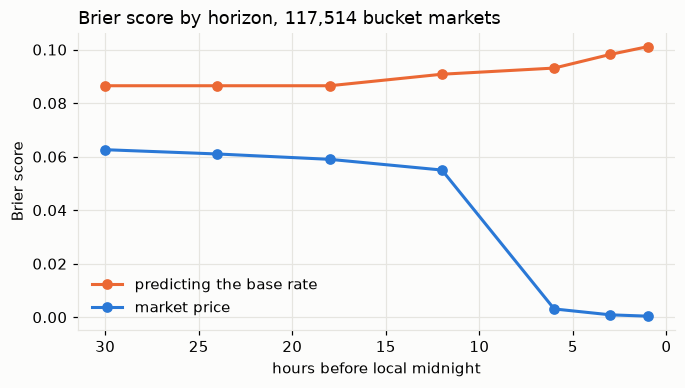

In [3]:
t1 = plots.table_after(t, "T1", "brier_market").sort_values("h", ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t1.h, t1.brier_base_rate, color=SERIES[1], lw=2, marker="o", label="predicting the base rate")
ax.plot(t1.h, t1.brier_market, color=SERIES[0], lw=2, marker="o", label="market price")
ax.invert_xaxis(); ax.set_xlabel("hours before local midnight"); ax.set_ylabel("Brier score")
ax.set_title("Brier score by horizon, 117,514 bucket markets"); ax.legend(frameon=False)
t1

## Reliability by price band at 24 hours

Hit rate against mean price per price band. A bias near zero means the prices are honest probabilities; the intervals are 95% on the hit rate.

In [4]:
rel = next(df for h, df in t if "Reliability" in h and "bias" in df.columns)
rel[rel.h == 24] if "h" in rel.columns else rel.head(12)

,h,band,n,mean_price,hit_rate,bias,ci95
12,24,0.00-0.02,62583,0.0042,0.0031,-0.0011,0.0004
13,24,0.02-0.05,10991,0.0318,0.0244,-0.0074,0.0029
14,24,0.05-0.10,8333,0.0707,0.0600,-0.0107,0.0051
15,24,0.10-0.20,9508,0.1456,0.1336,-0.0121,0.0068
16,24,0.20-0.35,12684,0.2725,0.2597,-0.0128,0.0076
17,24,0.35-0.50,8279,0.4103,0.4046,-0.0056,0.0106
18,24,0.50-0.65,2163,0.5557,0.5867,0.0310,0.0208
19,24,0.65-0.80,492,0.7040,0.7337,0.0297,0.0391
20,24,0.80-0.90,134,0.8501,0.8582,0.0081,0.0591
21,24,0.90-0.95,110,0.9245,0.9273,0.0028,0.0485


## Who loses: taker profit per fill (T4)

Takers lose on average in every resolution era; makers earn the mirror image before fees and rebates. Complete months are those where the fills dataset holds every trade.

In [5]:
t4 = plots.table_after(t, "T4", "taker_pnl_per_share")
t4[t4.complete_month == "True"][["era", "n_fills", "shares", "taker_pnl_usd", "taker_pnl_per_share", "share_taker_buys_yes"]]

,era,n_fills,shares,taker_pnl_usd,taker_pnl_per_share,share_taker_buys_yes
0,cwa,14183,7.048530e+05,4.466686e+02,0.0006,0.3209
1,hko,365995,1.212320e+07,-4.860263e+04,-0.0040,0.3636
3,noaa_wrh,504385,1.022104e+07,-4.595131e+03,-0.0004,0.3422
5,wunderground,15138062,4.540282e+08,-1.329826e+06,-0.0029,0.3692


## When markets appear

A two-days-out strategy can only quote after the market exists. NYC events are created a median 42 to 48 h before the local day for most of the history, only 27 h in mid-2026, and 44 h again since September 2026.

,month,events,median_hours_before_day,exist_at_noon_two_days_before
14,2026-03,31,42.0,29
15,2026-04,30,47.9,29
16,2026-05,32,47.9,30
17,2026-06,29,27.0,5
18,2026-07,31,27.0,0
19,2026-08,31,27.0,2
20,2026-09,30,44.1,29
21,2026-10,1,44.1,1


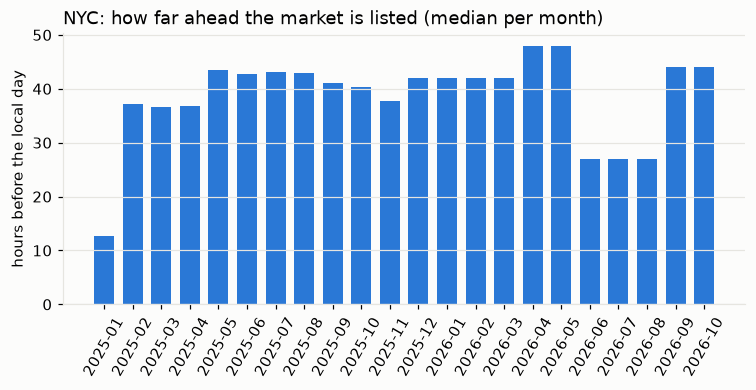

In [6]:
con = duckdb.connect("data/research.duckdb", read_only=True); con.execute("SET enable_progress_bar=false")
lead = con.execute("""
WITH e AS (SELECT event_id, date, min(created_at) AS created,
                  ((date::TIMESTAMP AT TIME ZONE 'America/New_York') AT TIME ZONE 'UTC') AS day_start
           FROM markets WHERE station = 'KLGA' GROUP BY 1, 2)
SELECT strftime(date, '%Y-%m') AS month, count(*) AS events,
       round(median(epoch(day_start - created) / 3600.0), 1) AS median_hours_before_day,
       count(*) FILTER (WHERE created <= day_start - INTERVAL 36 HOUR) AS exist_at_noon_two_days_before
FROM e GROUP BY 1 ORDER BY 1""").df()
con.close()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(lead.month, lead.median_hours_before_day, color=SERIES[0], width=0.7)
ax.set_ylabel("hours before the local day"); ax.set_title("NYC: how far ahead the market is listed (median per month)")
ax.tick_params(axis="x", rotation=60); ax.grid(axis="x", visible=False)
lead.tail(8)